<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 14px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 15px;">
    BinX Tech — AI & ML Internship · Week 7 · Day 1
</div>

<h1 style="font-size: 38px; margin: 0; font-weight: 700;">
    Sprint 2 Planning & CNN Introduction
</h1>

<p style="font-size: 20px; margin-top: 12px; opacity: 0.95;">
    Convolutional Neural Networks — Filters, Feature Maps & Parameter Sharing
</p>

</div>

## Sprint 2 Plan

**Duration:** Week 7 — 5 days
**Project:** Cardiac Patient Monitoring System
**Dataset change:** Replacing `heart.csv` (918 rows) with the Cardiovascular Disease Dataset (70,000 patients) from Kaggle.

---

### Why the Dataset Changed

Sprint 1 showed that the neural network could not beat the Random Forest on a dataset of 918 rows.
The retrospective identified dataset size as a key limiting factor — neural networks need sufficient
data to learn meaningful representations. The Cardiovascular Disease Dataset (70,000 patients,
same binary classification task, clean data with no zero-imputed values) gives the neural network
a genuine opportunity to demonstrate its advantage over classical models at scale.

The task and domain remain the same: binary classification of cardiovascular risk from clinical measurements.

---

### Sprint 2 Goal

Train and tune a Dense Network on the new 70K dataset that beats the RF Baseline established
on that same dataset. Target: **F1 > RF** and **AUC-ROC > RF** on the held-out test set.

---

### Sprint 2 Backlog

| # | Task | Deliverable | Day |
|---|------|-------------|-----|
| 1 | Sprint 2 planning + CNN intro + dataset decision | `day1_sprint2_planning_cnn_intro.ipynb` | Day 1 |
| 2 | CNN from scratch + augmentation + transfer learning (Melanoma) | `day2_cnn_transfer_learning.ipynb` | Day 2 |
| 3 | RNNs & LSTMs + Mentor Code Review | `day3_rnn_lstm.ipynb` | Day 3 |
| 4 | Attention mechanism + Transformers | `day4_attention_transformers.ipynb` | Day 4 |
| 5 | Core model on 70K dataset + Sprint Review + Retrospective | `day5_sprint2_review.ipynb` | Day 5 |

---

### Definition of Done

- All notebooks run without errors
- CNN notebook completed on Melanoma dataset (Day 2)
- Core model on 70K cardiovascular data beats RF Baseline
- Every experiment logged in a structured table from Day 1
- All work committed to GitHub via Sprint 2 feature branch
- Sprint Review and Retrospective written on Day 5

---

### Concrete Improvement from Sprint 1 Retrospective

> "In Sprint 2, I will keep a structured experiment log from the beginning,
> recording each model configuration, validation metrics, and training behavior."

The experiment log starts in this notebook and carries forward through every Day 2–5 notebook.

---

### Architecture Decision

| Data Type | Architecture | Reason |
|-----------|-------------|--------|
| Tabular (cardiovascular) | Dense Network | No spatial or sequential structure |
| Images (melanoma) | CNN + Transfer Learning | Spatial structure — studied Day 2 |
| Sequential (TBD from mentor) | RNN / LSTM | Order matters — studied Day 3 |

---

## Sprint 2 Experiment Log

This log records every model configuration and result across Sprint 2.

It starts with the Sprint 1 reference results and will be updated throughout the week as new experiments are performed.

The Sprint 1 results are kept as historical references. A new Random Forest baseline will be established on the 70K cardiovascular dataset before evaluating the Sprint 2 Dense Network.


In [ ]:
import pandas as pd

# Sprint 2 experiment log
# Start with Sprint 1 reference results.
# The new 70K Random Forest baseline will be added later.

experiment_log = pd.DataFrame([
    {
        "Sprint": "Sprint 1 — Reference",
        "Model": "RF Baseline",
        "Architecture": "Random Forest (200 trees)",
        "Key Config": "n_estimators=200",
        "Val F1": "—",
        "Test F1": 0.9005,
        "Test AUC": 0.9427,
        "Notes": "Sprint 1 reference result"
    },
    {
        "Sprint": "Sprint 1 — Reference",
        "Model": "NN Final (tuned)",
        "Architecture": "Dense: 64 → 32",
        "Key Config": "BN + Dropout(0.3) + EarlyStopping(patience=15)",
        "Val F1": "~0.87",
        "Test F1": 0.8670,
        "Test AUC": 0.9182,
        "Notes": "Best neural network from Sprint 1"
    }
])

print("=" * 70)
print("              SPRINT 2 — EXPERIMENT LOG")
print("=" * 70)

display(experiment_log)

print("=" * 70)
print("Sprint 1 reference:")
print("  RF Baseline → F1: 0.9005 | AUC-ROC: 0.9427")
print()
print("Sprint 2 next step:")
print("  Establish a new RF baseline on the 70K cardiovascular dataset.")
print("=" * 70)

---

## Why Dense Networks Fail on Images

Dense networks treat every input as a flat list of numbers with no structure.
For tabular data like the cardiovascular dataset, that works fine — each feature
is independent. For images, it creates two serious problems.

**Problem 1 — Too many parameters**
A 200×200 color image contains 200 × 200 × 3 = 120,000 numbers. A dense first
layer with 256 neurons needs 120,000 × 256 = 30,720,000 weights — and that is
just one layer. This does not scale.

**Problem 2 — No spatial awareness**
Dense networks ignore a key property of images: nearby pixels are related, and
the same pattern (an edge, a curve, a lesion boundary) looks the same wherever
it appears in the image. Dense networks have no way to use this structure.

Convolution solves both problems.

In [ ]:
# The numbers: why dense layers don't scale to images

scenarios = [
    ("64 × 64 grayscale",   64,  64, 1),
    ("200 × 200 color",    200, 200, 3),
    ("224 × 224 color",    224, 224, 3),  # standard CNN input size
]

print(f"{'Scenario':<22} {'Pixels':>10} {'Dense weights (256 neurons)':>28}")
print("-" * 65)

for name, h, w, c in scenarios:
    pixels = h * w * c
    dense  = pixels * 256
    print(f"{name:<22} {pixels:>10,} {dense:>28,}")

print()
print("A single dense layer with 256 neurons needs tens of millions of weights.")
print("CNN first layer (32 filters, 3×3): only", 32 * 3 * 3 * 3, "weights.")

Scenario                   Pixels  Dense weights (256 neurons)
-----------------------------------------------------------------
64 × 64 grayscale           4,096                    1,048,576
200 × 200 color           120,000                   30,720,000
224 × 224 color           150,528                   38,535,168

A single dense layer with 256 neurons needs tens of millions of weights.
CNN first layer (32 filters, 3×3): only 864 weights.


---

## Convolution: Filters and Feature Maps

Instead of connecting every neuron to every pixel, convolution slides a small
**filter** (or kernel) — typically 3×3 — across the image. At each position it
computes a dot product between the filter weights and the pixel values underneath.
The output is a **feature map**: a grid showing how strongly each location matched
the filter's pattern.

| Concept | Meaning |
|---------|---------|
| **Filter / Kernel** | A small learnable weight grid that detects one pattern |
| **Feature Map** | The output — shows where the pattern was found in the image |
| **Stride** | How many pixels the filter moves at each step |
| **Padding** | A border added so the filter can process edge pixels |

**Parameter sharing:** the same 9-weight filter is reused across the entire image.
One filter replaces thousands of dense connections.

**Translation invariance:** the filter detects a pattern wherever it appears —
top-left, center, or bottom-right — because it slides everywhere.

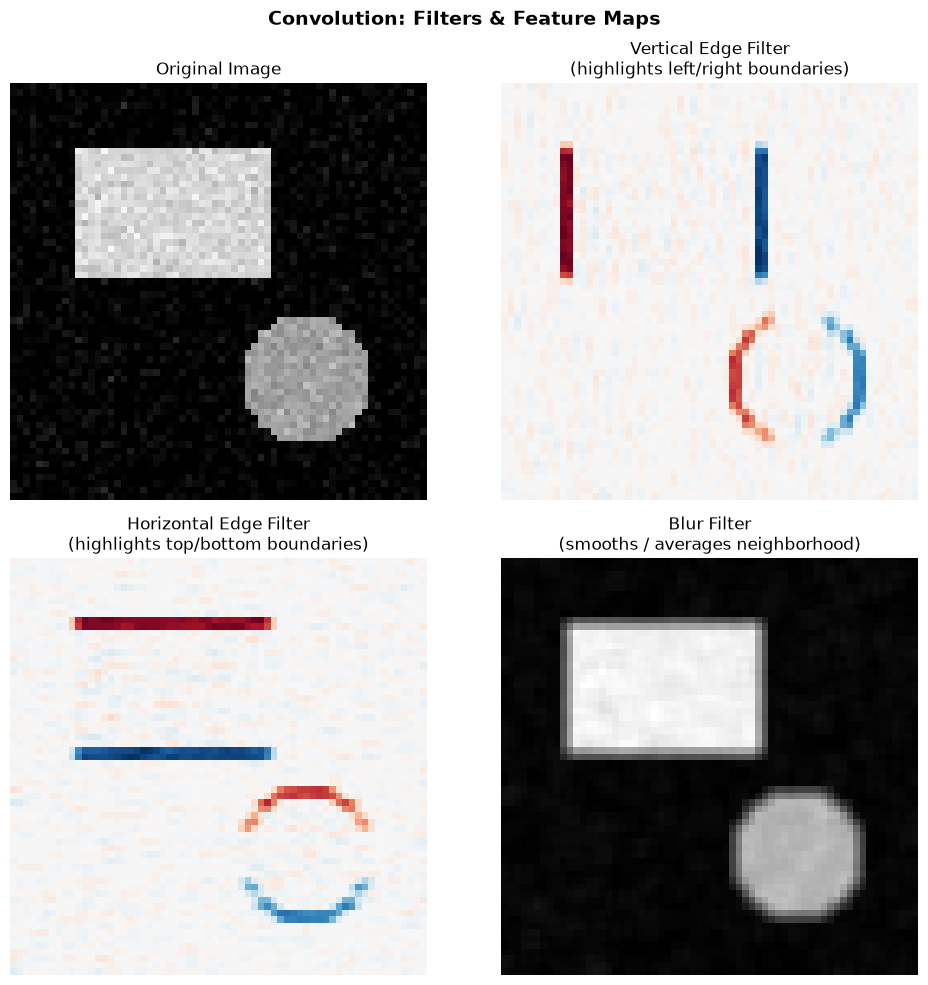

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

# Build a synthetic grayscale image with clear edges
np.random.seed(42)
img = np.zeros((64, 64), dtype=float)

# Rectangle — gives clean horizontal and vertical edges
img[10:30, 10:40] = 0.8

# Circular blob
for i in range(64):
    for j in range(64):
        if (i - 45) ** 2 + (j - 45) ** 2 < 100:
            img[i, j] = 0.6

# Add slight noise
img += np.random.normal(0, 0.05, img.shape)
img = np.clip(img, 0, 1)

# Define three filters
vertical_edge = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=float)

horizontal_edge = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

blur = np.ones((3, 3), dtype=float) / 9.0

# Apply convolution
fmap_vertical   = convolve(img, vertical_edge)
fmap_horizontal = convolve(img, horizontal_edge)
fmap_blur       = convolve(img, blur)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Convolution: Filters & Feature Maps", fontsize=14, fontweight="bold")

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fmap_vertical, cmap="RdBu")
axes[0, 1].set_title("Vertical Edge Filter\n(highlights left/right boundaries)")
axes[0, 1].axis("off")

axes[1, 0].imshow(fmap_horizontal, cmap="RdBu")
axes[1, 0].set_title("Horizontal Edge Filter\n(highlights top/bottom boundaries)")
axes[1, 0].axis("off")

axes[1, 1].imshow(fmap_blur, cmap="gray")
axes[1, 1].set_title("Blur Filter\n(smooths / averages neighborhood)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### What the Feature Maps Show

**Original image:**
Two shapes on a black background — a rectangle (top-left) and a circular blob
(bottom-right). Both have clear boundaries where pixel intensity changes sharply
from dark (background) to light (shape).

**Vertical Edge Filter (top-right):**
Strong red and blue values appear on the left and right sides of the rectangle,
and on the left and right sides of the circular blob. These are exactly the
locations where pixel intensity changes from left to right — a vertical boundary.
The top and bottom edges of the rectangle produced no response because they are
horizontal, not vertical. The flat interior of each shape also produced no response
because there is no change in intensity there.
Red = dark-to-light transition. Blue = light-to-dark transition.

**Horizontal Edge Filter (bottom-left):**
Strong values appear on the top and bottom edges of the rectangle, and on the
top and bottom of the circular blob — where intensity changes from top to bottom.
The left and right sides of the rectangle produced no response this time, because
they are vertical boundaries and this filter only responds to horizontal ones.
The same image, a different filter, a completely different set of edges detected.

**Blur Filter (bottom-right):**
The output looks like the original but with softer edges. The filter replaces each
pixel with the average of itself and its eight neighbors, so sharp transitions
become gradual. Instead of detecting anything, this filter removes detail —
the opposite of edge detection.

**The key insight:**
One filter = one question asked across the entire image.
The vertical filter asked: "where does intensity change left-to-right?"
The horizontal filter asked: "where does intensity change top-to-bottom?"
Each got a different answer from the same image.

In a trained CNN, the network learns its own filters automatically through
backpropagation — it discovers which questions are most useful for the task,
whether that is detecting lesion boundaries in melanoma images or recognizing
edges in any other visual pattern.

---

## Parameter Sharing: The Numbers

The filter demo above used 9 weights (3×3) to scan the entire 64×64 image.
A dense layer connecting the same image to a single output neuron would need
64 × 64 = 4,096 weights — for one neuron only.

This difference is called **parameter sharing**: the same filter weights are
reused at every position across the image instead of learning separate weights
for every pixel-to-neuron connection.

Two properties make this work:

**Parameter sharing** — one 3×3 filter (9 weights) replaces thousands of
dense connections. The network stays small and trains faster.

**Translation invariance** — because the filter slides everywhere, it detects
the same pattern no matter where it appears in the image. A filter that learned
to detect a lesion boundary in the top-left corner will detect it in the
bottom-right corner too — without retraining.

In [ ]:
import pandas as pd

# Dense vs convolution — parameter count comparison
print("Comparing parameter counts: Dense Layer vs Convolution\n")

scenarios = [
    ("64 × 64 grayscale",   64,  64, 1),
    ("128 × 128 grayscale", 128, 128, 1),
    ("200 × 200 color",     200, 200, 3),
    ("224 × 224 color",     224, 224, 3),
]

filter_weights = 3 * 3  # one 3×3 filter

rows = []
for name, h, w, c in scenarios:
    pixels        = h * w * c
    dense_weights = pixels
    saving        = dense_weights // filter_weights
    rows.append({
        "Image size"          : name,
        "Total pixels"        : f"{pixels:,}",
        "Dense weights*"      : f"{dense_weights:,}",
        "Conv filter weights" : filter_weights,
        "Saving factor"       : f"{saving:,}×"
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print("* Dense weights = connections from all pixels to ONE output neuron.")
print(f"  A first dense layer with 256 neurons multiplies this by 256.")
print(f"\nOne conv filter always uses {filter_weights} weights,",
      "reused across the entire image.")

Comparing parameter counts: Dense Layer vs Convolution

         Image size Total pixels Dense weights*  Conv filter weights Saving factor
  64 × 64 grayscale        4,096          4,096                    9          455×
128 × 128 grayscale       16,384         16,384                    9        1,820×
    200 × 200 color      120,000        120,000                    9       13,333×
    224 × 224 color      150,528        150,528                    9       16,725×

* Dense weights = connections from all pixels to ONE output neuron.
  A first dense layer with 256 neurons multiplies this by 256.

One conv filter always uses 9 weights, reused across the entire image.


### What the Numbers Show

For a 64×64 grayscale image, one dense output neuron needs 4,096 weights.
One convolutional filter needs 9 — a saving of 455×.

For a 224×224 color image (the standard input size for most CNNs), the gap
grows to 16,725×. A dense first layer with 256 neurons on this image would
need 150,528 × 256 = **38,535,168 weights** — in a single layer.

The convolutional alternative: 32 filters of 3×3×3 = **864 weights** total.

This is why CNNs are the standard architecture for image tasks. The saving
is not just computational — fewer parameters means less overfitting and
better generalization, especially when training data is limited.

## The Feature Hierarchy

CNNs do not learn all patterns at once — they build a hierarchy across layers:

- **Early layers** detect simple patterns: edges, corners, color gradients
- **Middle layers** combine those into shapes and textures
- **Deep layers** recognize whole objects: a lesion, a face, a car

These features are not designed by hand — the network discovers them
automatically during training. This hierarchy is why deep CNNs generalize
so well: each layer builds on what the previous layer already learned.

---

## Summary — Day 1

| Topic | Key Takeaway |
|-------|-------------|
| Sprint 2 planning | New 70K cardiovascular dataset — target F1 > RF Baseline |
| Experiment log | Initialized with Sprint 1 references — grows throughout the week |
| Dense networks on images | Too many parameters — ignores spatial structure |
| Convolution | A small filter slides across the image computing dot products locally |
| Feature map | Shows where in the image the filter's pattern was found |
| Parameter sharing | One 3×3 filter replaces thousands of dense connections |
| Translation invariance | A pattern is detected wherever it appears in the image |
| Architecture decision | CNN for melanoma images — Dense Network for cardiovascular data |

**Tomorrow — Day 2:** Building a full CNN on the Melanoma dataset —
pooling layers, data augmentation, and transfer learning with a pretrained model.